# Data Analysis

This notebook analyses accelerated stability data for two prototype formulations:

- Lot A014: Formulation A
- Lot B025: Formulation B

The aim is to describe the dataset, explore stability trends, compare formulations, and build simple models that help explain degradation behaviour.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "KTP_task_datasets.xls"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.max_columns", 100)

## 1. Load and clean the dataset

The workbook contains one sheet per lot. The first row after the column headers contains duplicate-measurement labels, so the loader removes that row, standardises column names, converts numeric fields, and calculates replicate means and differences.

In [2]:
def load_stability_workbook(path: Path) -> pd.DataFrame:
    """Load the supplied KTP stability workbook and return a tidy dataframe."""
    sheet_to_formulation = {"Lot A014": "A", "Lot B025": "B"}
    frames = []

    for sheet_name, formulation in sheet_to_formulation.items():
        raw = pd.read_excel(path, sheet_name=sheet_name, header=0)
        raw.columns = raw.columns.str.strip()

        # Row 0 stores sample labels such as "sample 1" / "sample 2" rather than observations.
        df = raw.iloc[1:].copy()
        df = df.rename(columns={
            "Start Date": "start_date",
            "Pull Date": "pull_date",
            "Set down day": "set_down_day",
            "length of exposure (days)": "exposure_days",
            "Oven": "oven",
            "T (° C)": "temperature_c",
            "%RH": "rh",
            "Analyst": "analyst",
            "Assay (mg/tablet)": "assay_1",
            "Unnamed: 9": "assay_2",
            "Imp RRT 0.92 (%)": "imp092_1",
            "Unnamed: 11": "imp092_2",
            "IMP RRT 1.23 (%)": "imp123_1",
            "Unnamed: 13": "imp123_2",
        })
        df["lot"] = sheet_name.replace("Lot ", "")
        df["formulation"] = formulation

        numeric_cols = [
            "set_down_day", "exposure_days", "temperature_c", "rh",
            "assay_1", "assay_2", "imp092_1", "imp092_2", "imp123_1", "imp123_2",
        ]
        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # Control rows have non-numeric temperature/RH; keep them, but mark for modelling exclusion.
        df["is_control"] = df["temperature_c"].isna() | df["rh"].isna()

        for endpoint in ["assay", "imp092", "imp123"]:
            df[f"{endpoint}_mean"] = df[[f"{endpoint}_1", f"{endpoint}_2"]].mean(axis=1)
            df[f"{endpoint}_sd"] = df[[f"{endpoint}_1", f"{endpoint}_2"]].std(axis=1)
            df[f"{endpoint}_abs_diff"] = (df[f"{endpoint}_1"] - df[f"{endpoint}_2"]).abs()

        df["imp_total_mean"] = df["imp092_mean"] + df["imp123_mean"]
        df["imp_total_sd"] = np.sqrt(df["imp092_sd"] ** 2 + df["imp123_sd"] ** 2)
        frames.append(df)

    return pd.concat(frames, ignore_index=True)

stability = load_stability_workbook(DATA_PATH)
stability.head()

,start_date,pull_date,set_down_day,exposure_days,oven,temperature_c,rh,analyst,assay_1,assay_2,imp092_1,imp092_2,imp123_1,imp123_2,lot,formulation,is_control,assay_mean,assay_sd,assay_abs_diff,imp092_mean,imp092_sd,imp092_abs_diff,imp123_mean,imp123_sd,imp123_abs_diff,imp_total_mean,imp_total_sd
0,2025-12-18,2026-01-08,0.0,21.0,Oven 2,70.0,11.0,RG,8.185,8.119,0.288,0.282,0.074,0.074,A014,A,False,8.1520,0.046669,0.066,0.2850,0.004243,0.006,0.074,0.000000,0.000,0.3590,0.004243
1,2025-12-18,2026-01-08,0.0,21.0,Oven 4,65.0,25.0,SS,11.184,10.702,0.246,0.215,0.134,0.136,A014,A,False,10.9430,0.340825,0.482,0.2305,0.021920,0.031,0.135,0.001414,0.002,0.3655,0.021966
2,2025-12-18,2026-01-08,0.0,21.0,Oven 1,50.0,64.0,SS,12.100,12.238,0.222,0.222,0.191,0.189,A014,A,False,12.1690,0.097581,0.138,0.2220,0.000000,0.000,0.190,0.001414,0.002,0.4120,0.001414
3,2025-12-18,2026-01-08,0.0,21.0,Oven 3,60.0,80.0,CM,11.518,11.095,0.651,0.673,0.167,0.171,A014,A,False,11.3065,0.299106,0.423,0.6620,0.015556,0.022,0.169,0.002828,0.004,0.8310,0.015811
4,2025-12-18,2026-01-08,0.0,21.0,Oven 3,60.0,42.0,CM,11.813,11.294,0.527,0.541,0.176,0.176,A014,A,False,11.5535,0.366988,0.519,0.5340,0.009899,0.014,0.176,0.000000,0.000,0.7100,0.009899


In [3]:
print(f"Rows: {len(stability)}")
print(f"Columns: {stability.shape[1]}")
print("Rows by lot/formulation:")
display(stability.groupby(["lot", "formulation"]).size().rename("n_rows").to_frame())

print("Missing values in key fields:")
key_cols = ["start_date", "pull_date", "exposure_days", "temperature_c", "rh", "assay_mean", "imp092_mean", "imp123_mean"]
display(stability[key_cols].isna().sum().rename("missing_count").to_frame())

print("Experimental design summary excluding controls:")
display(stability.loc[~stability["is_control"], ["temperature_c", "rh", "exposure_days"]].describe().T)

Rows: 40
Columns: 28
Rows by lot/formulation:


,,n_rows
lot,formulation,
A014,A,20
B025,B,20


Missing values in key fields:


,missing_count
start_date,2
pull_date,2
exposure_days,0
temperature_c,2
rh,2
assay_mean,0
imp092_mean,0
imp123_mean,0


Experimental design summary excluding controls:


,count,mean,std,min,25%,50%,75%,max
temperature_c,38.0,62.631579,6.851400,50.0,60.00,65.0,70.0,70.0
rh,38.0,48.210526,23.949449,11.0,25.00,42.0,64.0,80.0
exposure_days,38.0,12.736842,7.978634,1.0,5.25,14.0,21.0,21.0


### Dataset observations

- There are 40 analytical rows: 20 per lot/formulation.
- Each test point has duplicate assay and impurity measurements.
- Two rows are labelled as controls and do not have numeric temperature or humidity; these are useful as reference material but are excluded from regression models using temperature/RH.
- Temperature, humidity and exposure duration are not fully factorial or independently varied. For example, many temperature/RH/time combinations appear once only. This limits causal interpretation and makes interaction terms exploratory.

## 2. Exploratory summaries and visual checks

In [4]:
summary = (
    stability.groupby(["lot", "formulation"])[["assay_mean", "imp092_mean", "imp123_mean", "imp_total_mean"]]
    .agg(["mean", "min", "max", "std"])
    .round(3)
)
display(summary)

assay_mean                       imp092_mean              \
                       mean    min     max    std        mean  min    max   
lot  formulation                                                            
A014 A               11.492  8.152  12.799  1.242       0.321  0.0  0.662   
B025 B               11.398  8.216  12.606  1.201       0.339  0.0  0.718   

                        imp123_mean                      imp_total_mean  \
                    std        mean    min    max    std           mean   
lot  formulation                                                          
A014 A            0.173       0.278  0.074  0.747  0.185          0.599   
B025 B            0.182       0.377  0.113  0.885  0.208          0.716   

                                       
                    min    max    std  
lot  formulation                       
A014 A            0.075  1.042  0.263  
B025 B            0.143  1.212  0.290

In [5]:
# Replicate precision: average absolute difference between duplicate measurements.
precision = (
    stability.groupby("formulation")[["assay_abs_diff", "imp092_abs_diff", "imp123_abs_diff"]]
    .mean()
    .rename(columns={
        "assay_abs_diff": "Assay mean abs. duplicate diff",
        "imp092_abs_diff": "Impurity 0.92 mean abs. duplicate diff",
        "imp123_abs_diff": "Impurity 1.23 mean abs. duplicate diff",
    })
    .round(4)
)
display(precision)

,Assay mean abs. duplicate diff,Impurity 0.92 mean abs. duplicate diff,Impurity 1.23 mean abs. duplicate diff
formulation,,,
A,0.2101,0.0182,0.0036
B,0.2172,0.0200,0.0034


Saved outputs\assay_vs_factors.png


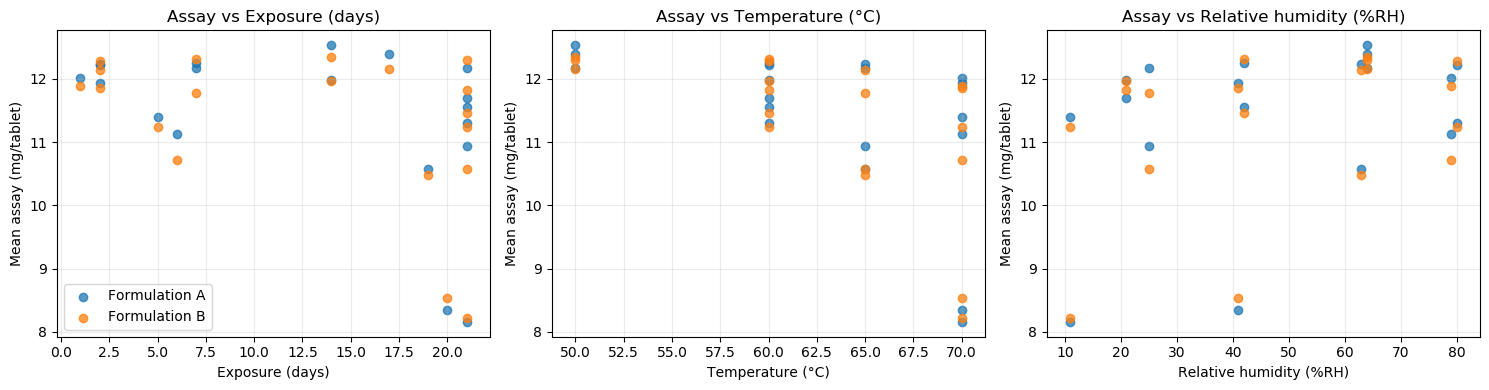

In [6]:
def save_current_fig(name: str) -> None:
    path = OUTPUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")

# Assay response vs experimental factors.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, x_col, x_label in zip(
    axes,
    ["exposure_days", "temperature_c", "rh"],
    ["Exposure (days)", "Temperature (°C)", "Relative humidity (%RH)"],
):
    for formulation, group in stability.loc[~stability["is_control"]].groupby("formulation"):
        ax.scatter(group[x_col], group["assay_mean"], label=f"Formulation {formulation}", alpha=0.75)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Mean assay (mg/tablet)")
    ax.set_title(f"Assay vs {x_label}")
axes[0].legend()
save_current_fig("assay_vs_factors.png")
plt.show()

Saved outputs\total_impurity_vs_factors.png


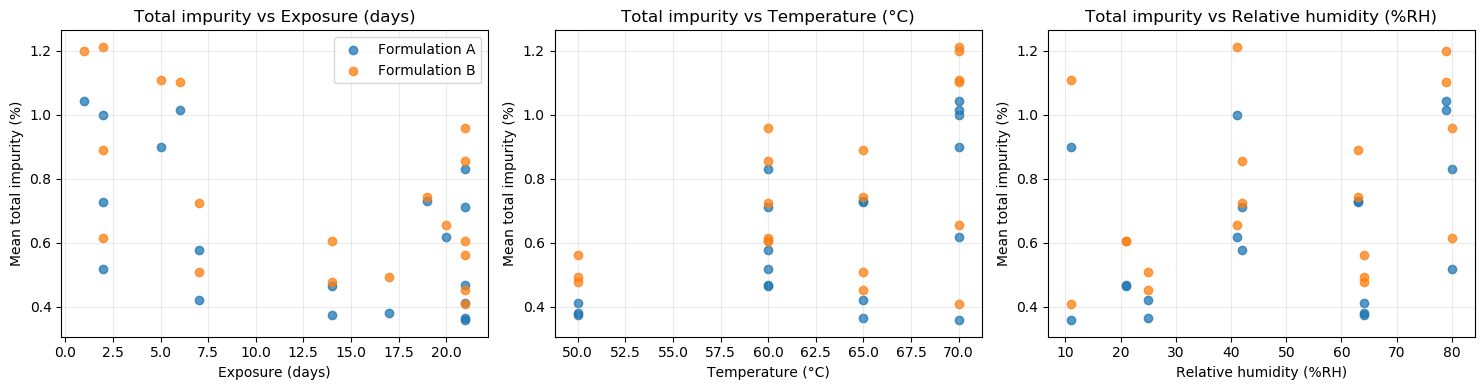

In [7]:
# Total impurity response vs experimental factors.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, x_col, x_label in zip(
    axes,
    ["exposure_days", "temperature_c", "rh"],
    ["Exposure (days)", "Temperature (°C)", "Relative humidity (%RH)"],
):
    for formulation, group in stability.loc[~stability["is_control"]].groupby("formulation"):
        ax.scatter(group[x_col], group["imp_total_mean"], label=f"Formulation {formulation}", alpha=0.75)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Mean total impurity (%)")
    ax.set_title(f"Total impurity vs {x_label}")
axes[0].legend()
save_current_fig("total_impurity_vs_factors.png")
plt.show()

Saved outputs\correlation_heatmap.png


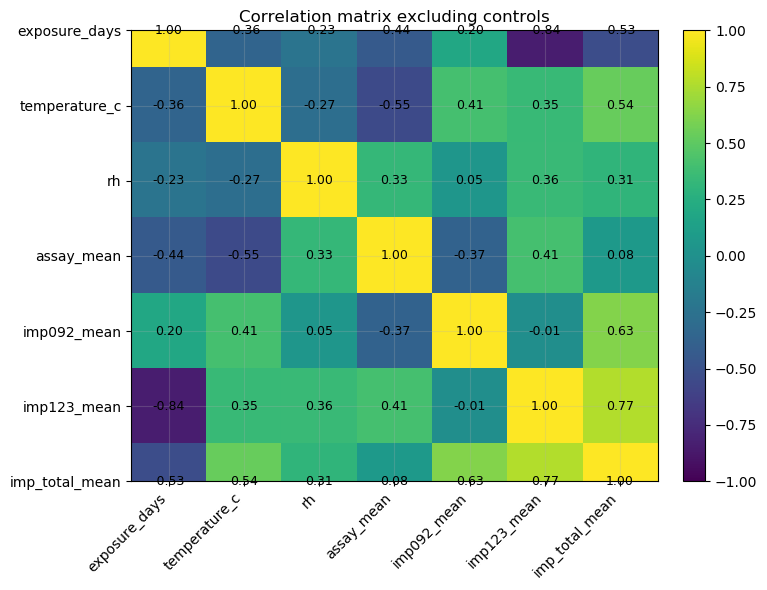

In [8]:
# Correlation heatmap for numeric factors/endpoints, excluding controls.
model_df = stability.loc[~stability["is_control"]].copy()
corr_cols = ["exposure_days", "temperature_c", "rh", "assay_mean", "imp092_mean", "imp123_mean", "imp_total_mean"]
corr = model_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")

ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation matrix excluding controls")

save_current_fig("correlation_heatmap.png")
plt.show()

### Main exploratory insights

- Assay tends to be lower at longer exposure and higher temperature.
- Impurity RRT 0.92 tends to increase with exposure, temperature and humidity.
- Impurity RRT 1.23 behaves differently: it is higher at short exposure points, and formulation B is consistently higher than A for this impurity.
- Total impurity is generally higher in formulation B, driven mainly by impurity RRT 1.23.

Because the design is imbalanced, these are associations rather than definitive mechanistic effects.

## 3. Modelling factors associated with degradation

The first modelling approach uses simple ordinary least squares models with exposure duration, temperature, relative humidity and formulation as predictors. This is interpretable and appropriate for a short analysis, but it should not be over-interpreted because observations are sparse and design variables are partially confounded.

In [9]:
endpoints = ["assay_mean", "imp092_mean", "imp123_mean", "imp_total_mean"]
models = {}
rows = []
for endpoint in endpoints:
    model = smf.ols(f"{endpoint} ~ exposure_days + temperature_c + rh + C(formulation)", data=model_df).fit()
    models[endpoint] = model
    for term, coef in model.params.items():
        rows.append({
            "endpoint": endpoint,
            "term": term,
            "coefficient": coef,
            "p_value": model.pvalues[term],
            "r_squared": model.rsquared,
        })

model_summary = pd.DataFrame(rows)
display(model_summary.round({"coefficient": 4, "p_value": 4, "r_squared": 3}))

,endpoint,term,coefficient,p_value,r_squared
0,assay_mean,Intercept,22.2676,0.0000,0.769
1,assay_mean,C(formulation)[T.B],-0.0893,0.6558,0.769
2,assay_mean,exposure_days,-0.1134,0.0000,0.769
3,assay_mean,temperature_c,-0.1474,0.0000,0.769
4,assay_mean,rh,-0.0035,0.4555,0.769
5,imp092_mean,Intercept,-0.9776,0.0011,0.427
6,imp092_mean,C(formulation)[T.B],0.0186,0.6616,0.427
7,imp092_mean,exposure_days,0.0111,0.0011,0.427
8,imp092_mean,temperature_c,0.0168,0.0001,0.427
9,imp092_mean,rh,0.0025,0.0162,0.427


Saved outputs\observed_vs_fitted_assay_mean.png


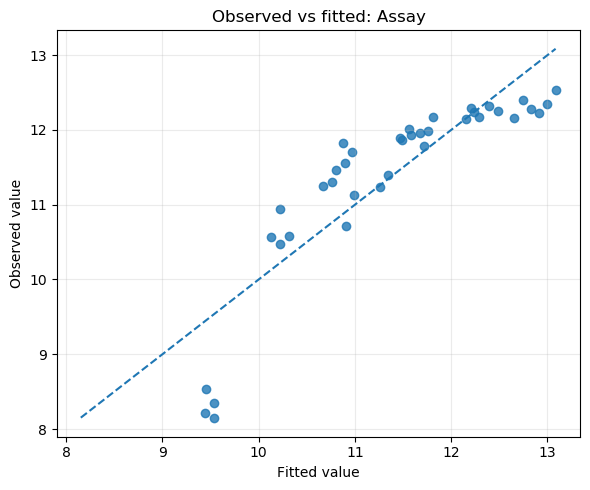

Saved outputs\observed_vs_fitted_imp_total_mean.png


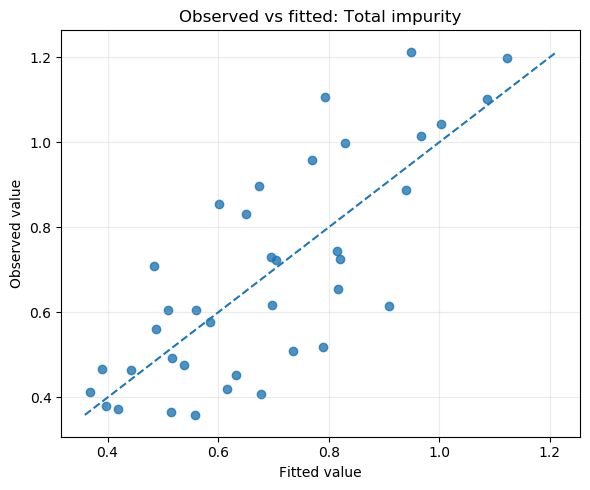

In [10]:
# Observed vs fitted plots for the two most decision-relevant endpoints.
for endpoint, label in [("assay_mean", "Assay"), ("imp_total_mean", "Total impurity")]:
    fitted = models[endpoint].fittedvalues
    observed = model_df[endpoint]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(fitted, observed, alpha=0.8)
    low, high = min(fitted.min(), observed.min()), max(fitted.max(), observed.max())
    ax.plot([low, high], [low, high], linestyle="--")
    ax.set_xlabel("Fitted value")
    ax.set_ylabel("Observed value")
    ax.set_title(f"Observed vs fitted: {label}")
    save_current_fig(f"observed_vs_fitted_{endpoint}.png")
    plt.show()

### Model interpretation

- **Assay:** The model explains a large share of the variation. Longer exposure and higher temperature are associated with lower assay. Humidity is less influential for assay in this dataset.
- **Impurity RRT 0.92:** Exposure, temperature and humidity all show positive associations, consistent with accelerated degradation.
- **Impurity RRT 1.23:** Formulation B has a higher fitted level than A. Exposure has a negative association, suggesting this impurity may be present early or may transform over time under some conditions rather than simply accumulate.
- **Total impurity:** Temperature and humidity are positive drivers, and formulation B has higher fitted total impurity than formulation A.

These models are useful for screening and communication, but they are not validated shelf-life models.

## 4. Relative performance of the two prototype formulations

In [11]:
comparison = (
    stability.groupby("formulation")[["assay_mean", "imp092_mean", "imp123_mean", "imp_total_mean"]]
    .agg(["mean", "median", "min", "max"])
    .round(3)
)
display(comparison)

paired_conditions = model_df.pivot_table(
    index=["exposure_days", "temperature_c", "rh"],
    columns="formulation",
    values=["assay_mean", "imp092_mean", "imp123_mean", "imp_total_mean"],
)
paired_delta = pd.DataFrame({
    "assay_B_minus_A": paired_conditions[("assay_mean", "B")] - paired_conditions[("assay_mean", "A")],
    "imp092_B_minus_A": paired_conditions[("imp092_mean", "B")] - paired_conditions[("imp092_mean", "A")],
    "imp123_B_minus_A": paired_conditions[("imp123_mean", "B")] - paired_conditions[("imp123_mean", "A")],
    "total_imp_B_minus_A": paired_conditions[("imp_total_mean", "B")] - paired_conditions[("imp_total_mean", "A")],
}).reset_index()

display(paired_delta.describe().T.round(3))

assay_mean                        imp092_mean                     \
                  mean  median    min     max        mean median  min    max   
formulation                                                                    
A               11.492  11.959  8.152  12.799       0.321  0.283  0.0  0.662   
B               11.398  11.845  8.216  12.606       0.339  0.296  0.0  0.718   

            imp123_mean                      imp_total_mean                \
                   mean median    min    max           mean median    min   
formulation                                                                 
A                 0.278  0.196  0.074  0.747          0.599  0.547  0.075   
B                 0.377  0.310  0.113  0.885          0.716  0.636  0.143   

                    
               max  
formulation         
A            1.042  
B            1.212

,count,mean,std,min,25%,50%,75%,max
exposure_days,19.0,12.737,8.089,1.000,5.500,14.000,21.000,21.000
temperature_c,19.0,62.632,6.946,50.000,60.000,65.000,70.000,70.000
rh,19.0,48.211,24.280,11.000,25.000,42.000,64.000,80.000
assay_B_minus_A,19.0,-0.089,0.178,-0.417,-0.174,-0.089,0.061,0.194
imp092_B_minus_A,19.0,0.019,0.028,-0.053,0.006,0.017,0.029,0.079
imp123_B_minus_A,19.0,0.101,0.033,0.039,0.071,0.106,0.128,0.154
total_imp_B_minus_A,19.0,0.119,0.053,0.013,0.087,0.127,0.148,0.212


Saved outputs\matched_total_impurity_delta.png


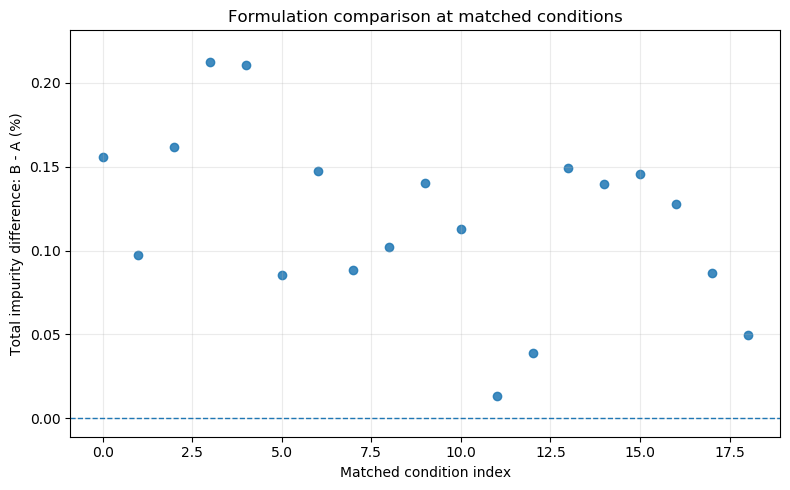

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
positions = np.arange(len(paired_delta))
ax.axhline(0, linestyle="--", linewidth=1)
ax.scatter(positions, paired_delta["total_imp_B_minus_A"], alpha=0.85)
ax.set_xlabel("Matched condition index")
ax.set_ylabel("Total impurity difference: B - A (%)")
ax.set_title("Formulation comparison at matched conditions")
save_current_fig("matched_total_impurity_delta.png")
plt.show()

### Recommendation

Formulation **A014 / Formulation A** appears preferable on the available evidence. Assay performance is broadly similar between lots, but formulation B shows higher impurity RRT 1.23 and higher total impurity in both raw summaries and adjusted modelling. The recommendation is therefore to prioritise Formulation A for further development, while confirming the finding in a more balanced stability study.

Uncertainty remains because this is a small accelerated study, replicate measurements are analytical duplicates rather than independent batches, and temperature/RH/time effects are not fully separable.

## 5. Additional modelling opportunities

For this dataset, modelling should remain simple and transparent. The current OLS models are useful because they estimate adjusted associations and provide a concise comparison between formulations.

Further approaches that could add value with more data:

1. **Response-surface models** with temperature × humidity × time terms, if a balanced design is collected.
2. **Kinetic models** for assay loss or impurity formation, if repeated time points are generated at the same storage condition.
3. **Arrhenius-type temperature acceleration models**, if enough temperatures are studied at controlled humidity and comparable durations.
4. **Mixed-effects models**, if future studies include multiple batches, analysts, ovens and repeated runs.

In this dataset, complex models would mainly fit noise because there are only 38 non-control condition rows and limited replication at each condition.

## 6. Limitations and future study recommendations

Key limitations:

- Small sample size and sparse coverage of the experimental space.
- Temperature, humidity and exposure duration are not fully crossed.
- Only one lot per formulation, so formulation and lot/batch effects cannot be separated.
- Duplicate values are analytical duplicates, not independent stability replicates.
- Control rows lack numeric temperature/RH and are limited as references.
- No explicit acceptance criteria are provided for assay or impurities.

Priorities for future studies:

1. Use a balanced factorial or response-surface design across temperature, humidity and time.
2. Include multiple independent batches per formulation.
3. Add repeated pulls at common conditions to estimate degradation rates.
4. Include long-term and intermediate ICH-style stability conditions alongside accelerated conditions.
5. Predefine acceptance criteria and decision thresholds.
6. Track packaging, water content and other formulation variables that could mechanistically explain humidity sensitivity.

In [13]:
# Optional: save a cleaned analysis table for local inspection.
clean_columns = [
    "lot", "formulation", "start_date", "pull_date", "set_down_day", "exposure_days",
    "oven", "temperature_c", "rh", "analyst", "is_control",
    "assay_mean", "imp092_mean", "imp123_mean", "imp_total_mean",
    "assay_abs_diff", "imp092_abs_diff", "imp123_abs_diff",
]
stability[clean_columns].to_csv(OUTPUT_DIR / "cleaned_stability_analysis_table.csv", index=False)
print("Saved cleaned analysis table locally.")

Saved cleaned analysis table locally.
